In [56]:
from google.colab import drive
import os
import numpy as np
import matplotlib.pyplot as plt
import astropy.io.fits as fits
from scipy.integrate import quad
from scipy import integrate as intg
import sympy as sp
from scipy import stats
from scipy.interpolate import UnivariateSpline
import pandas as pd
from scipy.stats import linregress
from scipy.stats import norm
import os
import seaborn as sns
from matplotlib import pyplot as plt, patches
import scipy
rng = np.random.default_rng()

from scipy.interpolate import CubicSpline

from scipy.fft import fft, ifft

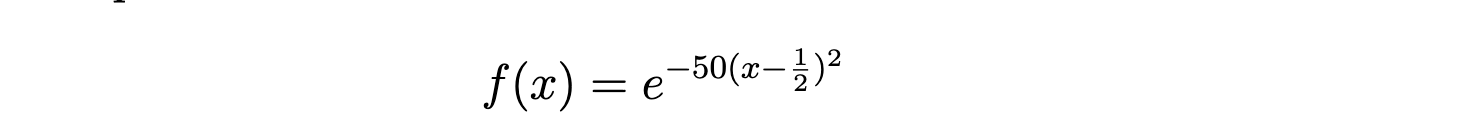

In [57]:
color1,color2,color3,color4 = '#D76A03','#4169E1','#a52422','#8EA604'


#Equation 1
def func1(x):
  y=np.e**(-50*(x-.5)**2)
  return y


#The eq labeled (3) in our problem gives the DFT function which we have as func1b3 ...
#func1b4 ccoresponds to IDFT from eq (4) in the problem
def func1b3(x1):

  N=len(x1)
  #N=(len(X))
  n=np.arange(N)
  k=n.reshape((N,1))

  #X = np.dot(e, x) #dot product of two varriables meks it a lot easier, helpful guide at [1]
  return np.dot(np.exp(-2j * np.pi * k * n / N),x1)




#NOW FOR THE inverse DFT or equation (4) in the hw doc
def func1b4(x2):
  N=len(x2)
  n=np.arange(N)
  k=n.reshape((N,1))
  e=np.exp(2j*np.pi*k*n/N)
  #X = np.dot(e, x2)
  return (1/N) * np.dot(np.exp(2j*np.pi*k*n/N),x2)#dot product again [1]





#
##had lots of problems with the dft eqs, but this site helped a lot.
#[https://pythonnumericalmethods.studentorg.berkeley.edu/notebooks/chapter24.02-Discrete-Fourier-Transform.html]

In [58]:
#print (Q1BNumerical)
## applying the function from the eq, e**(-50*(x-.5)**2) over the sample of 150,300, and 400 like the arrays in the above cell^


#assemble the sum range, ill just do 3 forr now, maybe a bigger range int he future but I just wanna make sure it works forst
arraytest150 = np.linspace(0, 1, 150)
arraytest300 = np.linspace(0, 1, 300)
arraytest400 = np.linspace(0, 1, 400)


Q1BNumerical = func1b3(func1(arraytest150))
Q1BNumerical = func1b3(func1(arraytest300))
Q1BNumerical = func1b3(func1(arraytest400))


#print (Q1BNumerical)


Q1BNumerical1A = func1b4(func1(arraytest150))
Q1BNumerical1B = func1b4(func1(arraytest300))
Q1BNumerical1C = func1b4(func1(arraytest400))


#print (Q1BNumerical1C)


#print (func1(arraytest))


/tmp/ipykernel_4179/2277205744.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc='upper left', fontsize=20)


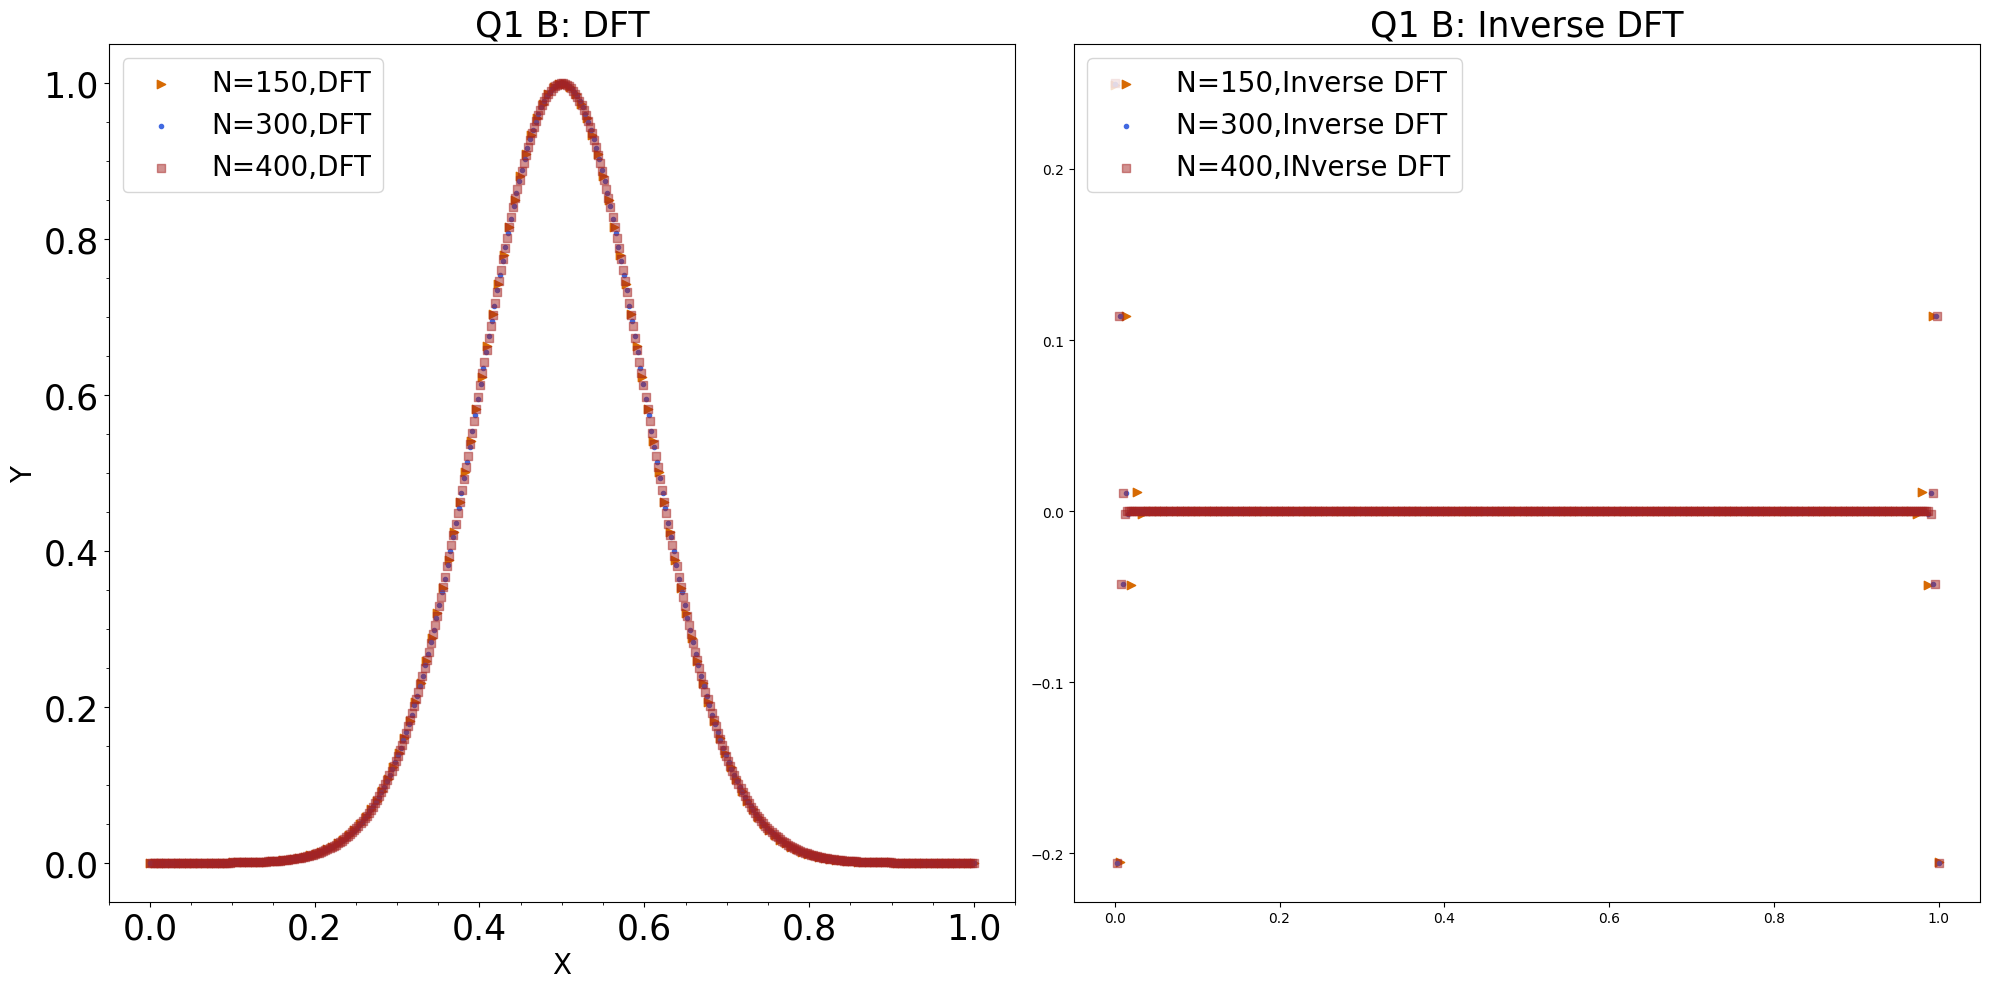

In [59]:
#plotting q1 B
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))


#ax1.plot(x_rk1, y_rk1, color='#a52422', linestyle='dotted', linewidth=12, label='RK4, 50 steps')



ax1.set_xlabel("X", fontsize=20)
ax1.set_ylabel("Y", fontsize=20)
ax1.tick_params(axis='both', which='major', labelsize=25)
ax1.legend(loc='upper left', fontsize=20)
ax1.minorticks_on()

ax1.scatter(arraytest150, func1(arraytest150),label="N=150,DFT",c=color1,marker='>')
ax1.scatter(arraytest300, func1(arraytest300),label="N=300,DFT",c=color2,marker='.')
ax1.scatter(arraytest400, func1(arraytest400),label="N=400,DFT",c=color3,marker='s',alpha=.5)

#plt.savefig('Fig1',dpi = 300
ax2.scatter(arraytest150, np.real(Q1BNumerical1A), label="N=150,Inverse DFT", c=color1, marker='>')
ax2.scatter(arraytest300, np.real(Q1BNumerical1B), label="N=300,Inverse DFT", c=color2, marker='.')
ax2.scatter(arraytest400, np.real(Q1BNumerical1C), label="N=400,INverse DFT", c=color3, marker='s', alpha=.5)
ax1.legend(loc='upper left', fontsize=20)
ax2.legend(loc='upper left', fontsize=20)


ax1.set_title("Q1 B: DFT", fontsize=25)
ax2.set_title("Q1 B: Inverse DFT", fontsize=25)



#plt.savefig('Fig1',dpi = 300)
plt.tight_layout()
plt.show()

plt.show()

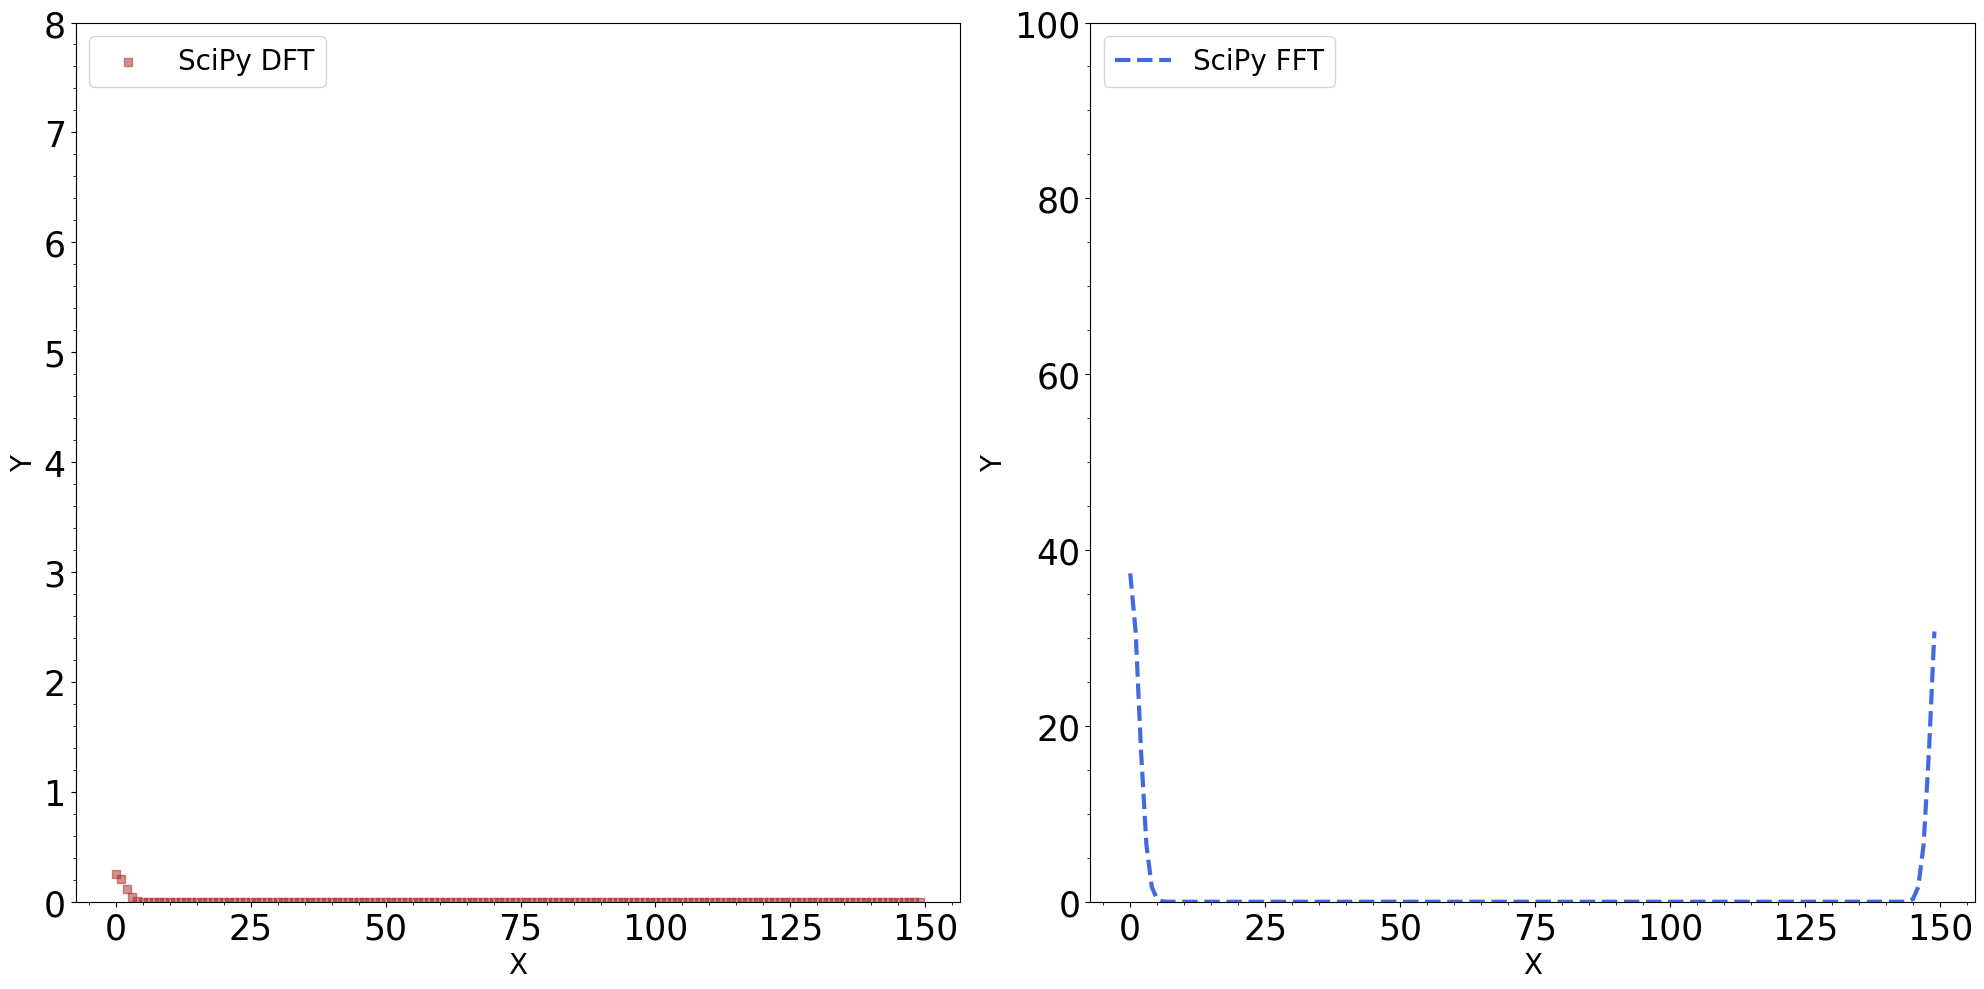

In [60]:
#Plotting Q 1 C

Q1Cscipy = np.fft.fft(func1(arraytest150))



fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

#ax1.plot(x_ex1, y_ex1, 'k-', linewidth=6, label='y = tan(x)')
#ax1.plot(x_e1, y_e1, color=color4, linestyle='--', linewidth=6, label='Euler, 50 steps')
#ax1.plot(x_rk1, y_ex1,linewidth=2, label='RK4')

ax1.scatter(np.arange(150), np.abs(Q1BNumerical1C[:150]), label="SciPy DFT", c=color3, marker='s', alpha=0.5)


ax1.set_ylim(0, 8)
ax1.set_xlabel("X", fontsize=20)
ax1.set_ylabel("Y", fontsize=20)
ax1.tick_params(axis='both', which='major', labelsize=25)
ax1.legend(loc='upper left', fontsize=20)
ax1.minorticks_on()



#ax2.plot(x_ex2, y_ex2, 'k-', linewidth=6, label='y = tan(x)')
#ax2.plot(x_e2, y_e2, color=color4, linestyle='--', linewidth=6, label='Euler, 10 steps')
#ax2.plot(x_rk2, y_rk2, color='#a52422', linestyle='dotted', linewidth=12, label='RK4, 10 steps')




ax2.plot(np.arange(150), np.abs(Q1Cscipy[:150]), label="SciPy FFT", color=color2, linewidth=3, linestyle='dashed')

ax2.set_ylim(0, 100)
ax2.set_xlabel("X", fontsize=20)
ax2.set_ylabel("Y", fontsize=20)
ax2.tick_params(axis='both', which='major', labelsize=25)
ax2.legend(loc='upper left', fontsize=20)
ax2.minorticks_on()

#plt.savefig('Fig1',dpi = 300)
plt.tight_layout()
plt.show()

plt.show()

In [61]:
#Question 1C:















#Baisically jsut need the scipy docc to figure it out
#  [2] https://docs.scipy.org/doc/scipy/tutorial/fft.html


QUESTION 2


In [62]:

#Bringing everything over from Integration
def EulerTest(x0, y0, xn, n):
    h = (xn - x0) / n
    ARRR1, BRRR1 = [x0], [y0]

    # Simple Euler step
    for i in range(n):
        y0 += h * prob1func(x0, y0)
        x0 += h
        ARRR1.append(x0)
        BRRR1.append(y0.copy())

    return ARRR1, BRRR1
def RKtest(x0, y0, xn, n,function):
    h = (xn - x0) / n
    ARRR1, BRRR1 = [x0], [y0]

    for i in range(n):
        k1 = h * function(x0, y0)
        k2 = h * function(x0 + h/2, y0 + k1/2)
        k3 = h * function(x0 + h/2, y0 + k2/2)
        k4 = h * function(x0 + h, y0 + k3)

        k = (k1 + 2*k2 + 2*k3 + k4) / 6
        y0 = y0 + k
        x0 = x0 + h

        ARRR1.append(x0)
        BRRR1.append(y0.copy())

    return ARRR1, BRRR1

